<a href="https://colab.research.google.com/github/jenny005/geo-koopman/blob/main/koopman_pendulum_ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GeoKoop pendulum ablation

This notebook tests whether the matrix-times-state structure `(K + N(z))·z`
in GeoKoop is doing geometric work, or whether any state-dependent residual
correction would do equally well.

**Five conditions** (5 seeds each, eps fixed at 1.0):

| Name | Dynamics | Purpose |
|---|---|---|
| `deep` | $z' = K z$ | Pure deep Koopman baseline |
| `vec_wm` | $z' = K z + g(z)$, hidden=32 | Vector correction, width-matched |
| `vec_pm` | $z' = K z + g(z)$, hidden=37 | Vector correction, **parameter-matched** to geo |
| `geo_nogeo` | $z' = (K + N(z)) z$, $\lambda_\text{geo}=0$ | GeoKoop without regularizer |
| `geo` | $z' = (K + N(z)) z$, $\lambda_\text{geo}=0.01$ | Your current method |

The load-bearing comparison is **`geo` vs `vec_pm`**. They have the same
parameter count, the same training protocol, the same eps. They differ only
in whether the correction is a matrix multiplied into `z` or a free vector
added to `K z`.

If `geo` clearly beats `vec_pm` across the seed std, the matrix structure
matters. If they overlap, the geometric framing is in trouble.

Each completed run is checkpointed to Drive immediately, so disconnects
cost one run, not all of them. Re-running the sweep cell resumes where
it left off.


## 1. Mount Drive and set up paths

Save directory matches what you set: `/content/drive/MyDrive/dG_experiment`.
Inside it we make a `runs/` subfolder for per-(condition, seed) JSONs and
a `figures/` subfolder for the final plots.


In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')



SAVE_DIR = '/content/drive/MyDrive/Koopman/DeepKoopman_data'
RUNS_DIR = os.path.join(SAVE_DIR, 'runs')          # per-run JSON files
FIGS_DIR = os.path.join(SAVE_DIR, 'figures')       # final plots
os.makedirs(RUNS_DIR, exist_ok=True)
os.makedirs(FIGS_DIR, exist_ok=True)

print(f'Save dir: {SAVE_DIR}')
print(f'Existing runs: {len(os.listdir(RUNS_DIR))}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save dir: /content/drive/MyDrive/Koopman/DeepKoopman_data
Existing runs: 0


## 2. Imports and config

`SEEDS = [0,1,2,3,4]` gives 5 seeds per condition. `EPS = 1.0` is fixed
for all correction-bearing models (Option B — no per-condition eps tuning).
If you want to revisit this later, change `EPS` and rerun; the resume
logic uses filenames that don't include eps, so to do a fresh sweep at a
different eps you should empty `RUNS_DIR` or change `RUNS_DIR`.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import json
import time
from collections import defaultdict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

# Sweep config
SEEDS         = [0, 1, 2, 3, 4]
EPS           = 1.0                # fixed; Option B
EPOCHS        = 3000
PHASE2_START  = 1000               # phase 1 = recon-only warmup
ROLLOUT_K     = 20                 # rollout horizon during training
LAM_GEO       = 0.01               # regularizer coefficient
HIDDEN_GEO    = 32                 # correction-net hidden width for geo
HIDDEN_VEC_WM = 32                 # width-matched VecKoop (fewer params)
HIDDEN_VEC_PM = 37                 # param-matched VecKoop (≈ same params as geo)

# Sanity check that jacrev is available (needed for mechanism plot)
try:
    from torch.func import jacrev
    print('torch.func.jacrev available — mechanism plot will work')
except ImportError:
    print('WARNING: torch.func.jacrev not available; mechanism plot will be skipped')

Device: cuda
PyTorch: 2.11.0+cu128
torch.func.jacrev available — mechanism plot will work


## 3. Data: load the Lusch et al. pendulum dataset

The pendulum data is the same 51-step trajectories used in your existing
paper. You'll need to upload the CSV files to Drive once — they're small.

**Expected layout under `SAVE_DIR/data/`:**
```
Pendulum_train1_x.csv
Pendulum_val_x.csv
Pendulum_test_x.csv
```

Each file is `(n_traj * 51, 2)` and gets reshaped to `(n_traj, 51, 2)`.


In [6]:
DATA_DIR = os.path.join(SAVE_DIR, 'data')

def load_pendulum(data_dir, split, seq_len=51):
    path = os.path.join(data_dir, f'Pendulum_{split}_x.csv')
    raw = np.loadtxt(path, delimiter=',', dtype=np.float32)
    n_traj = raw.shape[0] // seq_len
    return raw[:n_traj * seq_len].reshape(n_traj, seq_len, raw.shape[1])

X_train_np = load_pendulum(DATA_DIR, 'train1')
X_val_np   = load_pendulum(DATA_DIR, 'val')
X_test_np  = load_pendulum(DATA_DIR, 'test')
print(f'Train: {X_train_np.shape}  Val: {X_val_np.shape}  Test: {X_test_np.shape}')

# Normalise using training statistics only (no leakage from val/test)
X_mean = X_train_np.mean(axis=(0, 1), keepdims=True)
X_std  = X_train_np.std(axis=(0, 1),  keepdims=True) + 1e-8
X_train_n = (X_train_np - X_mean) / X_std
X_val_n   = (X_val_np   - X_mean) / X_std
X_test_n  = (X_test_np  - X_mean) / X_std

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).to(device)

X_tr = to_tensor(X_train_n)
X_va = to_tensor(X_val_n)
X_te = to_tensor(X_test_n)

# Flatten consecutive pairs for the 1-step dynamics loss
x_t   = X_tr[:, :-1, :].reshape(-1, 2)
x_tp1 = X_tr[:, 1:,  :].reshape(-1, 2)
print(f'Training pairs: {x_t.shape[0]}')

Train: (3500, 51, 2)  Val: (1000, 51, 2)  Test: (500, 51, 2)
Training pairs: 175000


## 4. Architecture

The autoencoder is **identical across all conditions** so any rollout
difference comes from the dynamics, not the representation.

`KoopmanCore` is the unified module. The `mode` flag selects:

- `'deep'`: $z' = K z$ (no correction)
- `'vec'`:  $z' = K z + \varepsilon \cdot g(z)$ where $g: \mathbb{R}^d \to \mathbb{R}^d$
- `'geo'`:  $z' = (K + \varepsilon \cdot N(z)) z$ where $N: \mathbb{R}^d \to \mathbb{R}^{d \times d}$

**Zero-initialization of the correction's last layer** is what makes the
comparison fair: all three modes start training from pure deep Koopman.
If `vec` and `geo` train to different fixed points, it's because the
structural form of the correction matters, not because they had different
starting conditions.


In [7]:
class AE(nn.Module):
    """Shared autoencoder. 2D input -> 4D latent -> 2D output."""
    def __init__(self, n=2, d=4, hidden=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, d))
        self.decoder = nn.Sequential(
            nn.Linear(d, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, n))
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)


class KoopmanCore(nn.Module):
    """Unified Koopman core supporting deep / vec / geo modes.

    The correction network has identical trunk depth (2 hidden layers,
    Tanh activations) across vec and geo. Only the output head differs:
    vec outputs d numbers, geo outputs d*d numbers that get reshaped
    to a matrix.
    """
    def __init__(self, d=4, mode='geo', hidden=32, eps=1.0):
        super().__init__()
        assert mode in ('deep', 'vec', 'geo')
        self.d, self.mode, self.eps = d, mode, eps

        # K starts near identity; small noise breaks symmetry between
        # latent dimensions. Same init across all conditions.
        self.K = nn.Parameter(torch.eye(d) + 0.01 * torch.randn(d, d))

        if mode == 'geo':
            self.correction = nn.Sequential(
                nn.Linear(d, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, d * d))         # matrix output
            # Zero-init last layer so initial dynamics = pure Kz
            nn.init.zeros_(self.correction[-1].weight)
            nn.init.zeros_(self.correction[-1].bias)
        elif mode == 'vec':
            self.correction = nn.Sequential(
                nn.Linear(d, hidden), nn.Tanh(),
                nn.Linear(hidden, hidden), nn.Tanh(),
                nn.Linear(hidden, d))             # vector output
            nn.init.zeros_(self.correction[-1].weight)
            nn.init.zeros_(self.correction[-1].bias)
        # mode == 'deep': no correction network

    def forward(self, z):
        out = z @ self.K.T
        if self.mode == 'geo':
            B  = z.shape[0]
            Nz = self.correction(z).view(B, self.d, self.d)
            # batched matrix-vector: A[b] @ z[b] for each item in batch
            out = out + self.eps * torch.bmm(Nz, z.unsqueeze(-1)).squeeze(-1)
        elif self.mode == 'vec':
            out = out + self.eps * self.correction(z)
        return out

    def correction_norm(self, z):
        """Regularizer: Frobenius for geo, L2 for vec, 0 for deep.

        Penalises departure from pure linear dynamics, biasing the model
        towards the Koopman backbone where possible.
        """
        if self.mode == 'deep':
            return torch.tensor(0., device=z.device)
        B = z.shape[0]
        if self.mode == 'geo':
            Nz = self.correction(z).view(B, self.d * self.d)
            return torch.mean(torch.norm(Nz, dim=1))
        else:
            return torch.mean(torch.norm(self.correction(z), dim=1))


def spec_pen(K):
    """Soft penalty driving K's eigenvalues towards the unit circle.

    Keeps the linear backbone marginally stable rather than collapsing
    to a contraction (which would kill long rollouts).
    """
    ev = torch.linalg.eigvals(K.unsqueeze(0))
    return ((ev.abs() - 1.0) ** 2).mean()

## 5. Training function

Two-phase schedule, matching your existing pendulum script:

- **Phase 1** (epochs 0–999): recon + small dynamics weight + spec penalty.
  Lets the autoencoder learn a good representation before pinning it down
  with rollout supervision.
- **Phase 2** (epochs 1000–2999): full loss with rollout (20 steps) and
  geometry regularizer.

The validation criterion (used for best-checkpoint selection) is **recon
+ 1-step dynamics only** — same as your original script, so the ablation
is judged against the same yardstick the paper uses.

**Seed control**: `torch.manual_seed(seed)` and `np.random.seed(seed)`
are set inside `train()` so different conditions trained at the same seed
share the same RNG state for any random ops (data shuffling, init noise).


In [8]:
def train(seed, mode, hidden_corr, lam_geo, eps=EPS, verbose=False):
    """Train one model. Returns dict with metrics and trained modules."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    ae   = AE(n=2, d=4, hidden=64).to(device)
    koop = KoopmanCore(d=4, mode=mode, hidden=hidden_corr, eps=eps).to(device)

    # Per-parameter-group learning rates: autoencoder fast, Koopman slow,
    # correction medium. Same scheme as your original; correction group
    # is only added when the model has one.
    params = [{'params': ae.parameters(), 'lr': 1e-3},
              {'params': [koop.K],        'lr': 5e-5}]
    if mode != 'deep':
        params.append({'params': koop.correction.parameters(), 'lr': 5e-4})

    opt = torch.optim.Adam(params)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.5)

    best_val, best_state = 1e9, None

    for ep in range(EPOCHS):
        ae.train(); koop.train()
        opt.zero_grad()

        z     = ae.encode(x_t)
        z_nxt = ae.encode(x_tp1)

        loss_rec  = ((ae.decode(z) - x_t) ** 2).mean()
        loss_dyn  = ((koop(z) - z_nxt) ** 2).mean()
        loss_spec = spec_pen(koop.K)
        loss_geo  = koop.correction_norm(z)

        # Rollout loss only kicks in during phase 2; otherwise we'd
        # supervise rollouts before the AE has converged.
        loss_roll = torch.tensor(0., device=device)
        if ep >= PHASE2_START:
            zr = ae.encode(X_tr[:, 0, :]).detach()
            for k in range(ROLLOUT_K):
                zr = koop(zr)
                xt = ae.encode(X_tr[:, k+1, :]).detach()
                loss_roll = loss_roll + ((zr - xt) ** 2).mean()
            loss_roll = loss_roll / ROLLOUT_K

        if ep < PHASE2_START:
            loss = loss_rec + 0.1 * loss_dyn + 0.01 * loss_spec
        else:
            loss = (loss_rec
                    + 1.0 * loss_dyn
                    + 0.5 * loss_roll
                    + 0.01 * loss_spec
                    + lam_geo * loss_geo)

        loss.backward()
        nn.utils.clip_grad_norm_(
            list(ae.parameters()) + list(koop.parameters()), 0.5)
        opt.step(); sch.step()

        # Validate every 100 epochs, track best
        if ep % 100 == 0:
            ae.eval(); koop.eval()
            with torch.no_grad():
                zv    = ae.encode(X_va[:, :-1].reshape(-1, 2))
                zv_nx = ae.encode(X_va[:, 1:].reshape(-1, 2))
                val = (((ae.decode(zv) - X_va[:, :-1].reshape(-1, 2)) ** 2).mean()
                       + ((koop(zv) - zv_nx) ** 2).mean()).item()
            if val < best_val:
                best_val = val
                best_state = {
                    'ae':   {k: v.clone() for k, v in ae.state_dict().items()},
                    'koop': {k: v.clone() for k, v in koop.state_dict().items()}
                }
            if verbose and ep % 500 == 0:
                print(f'    ep={ep:4d} rec={loss_rec.item():.5f} '
                      f'dyn={loss_dyn.item():.5f} '
                      f'roll={loss_roll.item():.5f} val={val:.5f}')

    # Restore the best checkpoint before computing test metrics
    ae.load_state_dict(best_state['ae'])
    koop.load_state_dict(best_state['koop'])

    # Test-set metrics
    ae.eval(); koop.eval()
    with torch.no_grad():
        z     = ae.encode(X_te[:, :-1].reshape(-1, 2))
        z_nxt = ae.encode(X_te[:, 1:].reshape(-1, 2))
        rec_mse = ((ae.decode(z) - X_te[:, :-1].reshape(-1, 2)) ** 2).mean().item()
        dyn_mse = ((koop(z) - z_nxt) ** 2).mean().item()

        # 49-step rollout: mean error over test trajectories at each step
        zr = ae.encode(X_te[:, 0, :])
        rollout_errs = []
        for k in range(49):
            zr = koop(zr)
            err = torch.norm(ae.decode(zr) - X_te[:, k+1, :], dim=1).mean().item()
            rollout_errs.append(err)

    n_params_corr = (sum(p.numel() for p in koop.correction.parameters())
                     if mode != 'deep' else 0)

    return {
        'val_loss':     best_val,
        'test_rec':     rec_mse,
        'test_dyn':     dyn_mse,
        'rollout':      rollout_errs,
        'n_params':     n_params_corr,
        'ae_state':     {k: v.cpu() for k, v in ae.state_dict().items()},
        'koop_state':   {k: v.cpu() for k, v in koop.state_dict().items()},
        'ae':           ae,
        'koop':         koop,
    }

## 6. Sweep with checkpointing and resume

Each completed `(condition, seed)` pair is written to a JSON in
`RUNS_DIR/<condition>__seed<N>.json` immediately. The sweep cell:

1. Lists existing JSONs.
2. Skips any pair already on disk.
3. Trains the remaining pairs, writing JSON after each.

If Colab disconnects mid-sweep, just rerun the cell — it picks up where
it left off. The full sweep is 25 runs (5 conditions × 5 seeds); each
takes 1–3 minutes on a T4, so a fresh start finishes in 30–75 minutes.


In [9]:
CONDITIONS = [
    # (name,         mode,    hidden,         lam_geo)
    ('deep',         'deep',  None,           0.0),
    ('vec_wm',       'vec',   HIDDEN_VEC_WM,  LAM_GEO),
    ('vec_pm',       'vec',   HIDDEN_VEC_PM,  LAM_GEO),
    ('geo_nogeo',    'geo',   HIDDEN_GEO,     0.0),
    ('geo',          'geo',   HIDDEN_GEO,     LAM_GEO),
]


def run_path(cond, seed):
    return os.path.join(RUNS_DIR, f'{cond}__seed{seed}.json')


def already_done(cond, seed):
    return os.path.exists(run_path(cond, seed))


def save_run(cond, seed, result):
    """Strip torch tensors and save JSON."""
    blob = {k: v for k, v in result.items()
            if k not in ('ae', 'koop', 'ae_state', 'koop_state')}
    with open(run_path(cond, seed), 'w') as f:
        json.dump(blob, f, indent=2)


# Storage for trained seed-0 models (kept in RAM for the mechanism plot).
# If the session disconnects, the mechanism plot cell will retrain them
# from the saved best-checkpoint — see cell 8.
seed0_models = {}

t_sweep_start = time.time()
n_done, n_skip = 0, 0

for name, mode, hidden, lam in CONDITIONS:
    for seed in SEEDS:
        if already_done(name, seed):
            n_skip += 1
            continue
        t0 = time.time()
        r = train(seed=seed, mode=mode, hidden_corr=hidden, lam_geo=lam)
        save_run(name, seed, r)
        if seed == 0 and mode == 'geo':
            seed0_models[name] = r           # for mechanism plot
        n_done += 1
        print(f'[{name:11s} seed={seed}] '
              f'val={r["val_loss"]:.5f}  '
              f'rollout@49={r["rollout"][-1]:.4f}  '
              f'({time.time()-t0:.0f}s)')

print(f'\nSweep done. New runs: {n_done}, skipped: {n_skip}, '
      f'total time: {(time.time()-t_sweep_start)/60:.1f} min')

[deep        seed=0] val=0.00002  rollout@49=0.2481  (94s)
[deep        seed=1] val=0.00001  rollout@49=0.2280  (88s)
[deep        seed=2] val=0.00002  rollout@49=0.2597  (88s)
[deep        seed=3] val=0.00001  rollout@49=0.2465  (89s)
[deep        seed=4] val=0.00002  rollout@49=0.2548  (88s)
[vec_wm      seed=0] val=0.00002  rollout@49=0.0276  (133s)
[vec_wm      seed=1] val=0.00002  rollout@49=0.0290  (132s)
[vec_wm      seed=2] val=0.00002  rollout@49=0.0312  (133s)
[vec_wm      seed=3] val=0.00001  rollout@49=0.0211  (133s)
[vec_wm      seed=4] val=0.00002  rollout@49=0.0370  (133s)
[vec_pm      seed=0] val=0.00002  rollout@49=0.0258  (140s)
[vec_pm      seed=1] val=0.00002  rollout@49=0.0256  (140s)
[vec_pm      seed=2] val=0.00002  rollout@49=0.0262  (140s)
[vec_pm      seed=3] val=0.00001  rollout@49=0.0197  (140s)
[vec_pm      seed=4] val=0.00002  rollout@49=0.0270  (139s)
[geo_nogeo   seed=0] val=0.00002  rollout@49=0.0108  (147s)
[geo_nogeo   seed=1] val=0.00001  rollout@49=

## 7. Aggregate and summarize

Loads all per-run JSONs and computes mean ± std for each condition.
The headline table is printed and saved to `summary.json`.


In [10]:
def load_all_runs():
    """Load every JSON in RUNS_DIR and group by condition."""
    runs = defaultdict(list)
    for fn in sorted(os.listdir(RUNS_DIR)):
        if not fn.endswith('.json'): continue
        cond = fn.split('__')[0]
        with open(os.path.join(RUNS_DIR, fn)) as f:
            runs[cond].append(json.load(f))
    return runs


def summarize(runs):
    summary = {}
    for cond, lst in runs.items():
        rolls = np.array([r['rollout'] for r in lst])           # (n_seeds, 49)
        summary[cond] = {
            'n_seeds':       len(lst),
            'val_mean':      float(np.mean([r['val_loss'] for r in lst])),
            'val_std':       float(np.std( [r['val_loss'] for r in lst])),
            'rec_mean':      float(np.mean([r['test_rec'] for r in lst])),
            'rec_std':       float(np.std( [r['test_rec'] for r in lst])),
            'dyn_mean':      float(np.mean([r['test_dyn'] for r in lst])),
            'dyn_std':       float(np.std( [r['test_dyn'] for r in lst])),
            'rollout_mean':  rolls.mean(axis=0).tolist(),
            'rollout_std':   rolls.std(axis=0).tolist(),
            'rollout49_mean': float(rolls.mean(axis=0)[-1]),
            'rollout49_std':  float(rolls.std(axis=0)[-1]),
            'n_params':      lst[0]['n_params'],
        }
    return summary


runs = load_all_runs()
summary = summarize(runs)

# Pretty-print
print('=' * 78)
print(f'{"Condition":12s} {"n":>3s} {"n_par":>6s}  '
      f'{"val":>16s}  {"rollout@49":>16s}')
print('-' * 78)
for name in ['deep', 'vec_wm', 'vec_pm', 'geo_nogeo', 'geo']:
    if name not in summary: continue
    s = summary[name]
    print(f'{name:12s} {s["n_seeds"]:>3d} {s["n_params"]:>6d}  '
          f'{s["val_mean"]:.5f}±{s["val_std"]:.5f}  '
          f'{s["rollout49_mean"]:.4f}±{s["rollout49_std"]:.4f}')
print('=' * 78)

with open(os.path.join(SAVE_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSummary saved to {SAVE_DIR}/summary.json')

Condition      n  n_par               val        rollout@49
------------------------------------------------------------------------------
deep           5      0  0.00002±0.00000  0.2474±0.0108
vec_wm         5   1348  0.00002±0.00001  0.0292±0.0052
vec_pm         5   1743  0.00002±0.00000  0.0249±0.0026
geo_nogeo      5   1744  0.00001±0.00001  0.0123±0.0060
geo            5   1744  0.00002±0.00001  0.0269±0.0134

Summary saved to /content/drive/MyDrive/Koopman/DeepKoopman_data/summary.json


## 8. Rollout error plot

The headline figure: mean rollout error per step, with ±1 std bands across
seeds. Five lines, one per condition.

**What to look for:**
- `geo` (red) should sit below the other lines if the geometric framing
  is correct.
- The critical visual is `geo` vs `vec_pm`. If those two lines overlap
  within the std bands, the matrix structure isn't doing anything special.
- If `vec_pm` matches `geo` but `vec_wm` doesn't, the gap was purely
  about parameter count, not structure.


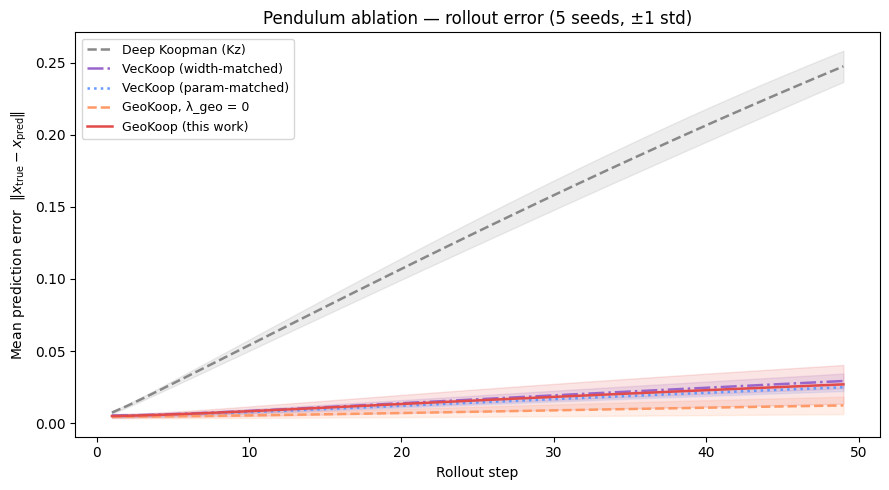

Saved /content/drive/MyDrive/Koopman/DeepKoopman_data/figures/rollout_comparison.png


In [11]:
def plot_rollout(summary, fname='rollout_comparison.png'):
    fig, ax = plt.subplots(figsize=(9, 5))
    ts = np.arange(1, 50)

    style = {
        'deep':      ('#888888', '--', 'Deep Koopman (Kz)'),
        'vec_wm':    ('#9966CC', '-.', 'VecKoop (width-matched)'),
        'vec_pm':    ('#6699FF', ':',  'VecKoop (param-matched)'),
        'geo_nogeo': ('#FF9966', '--', 'GeoKoop, λ_geo = 0'),
        'geo':       ('#E24B4A', '-',  'GeoKoop (this work)'),
    }

    for name in ['deep', 'vec_wm', 'vec_pm', 'geo_nogeo', 'geo']:
        if name not in summary: continue
        s = summary[name]
        c, ls, label = style[name]
        mean = np.array(s['rollout_mean'])
        std  = np.array(s['rollout_std'])
        ax.plot(ts, mean, color=c, ls=ls, lw=1.8, label=label)
        ax.fill_between(ts, mean - std, mean + std, color=c, alpha=0.15)

    ax.set_xlabel('Rollout step')
    ax.set_ylabel(r'Mean prediction error  $\|x_\mathrm{true} - x_\mathrm{pred}\|$')
    ax.set_title('Pendulum ablation — rollout error (5 seeds, ±1 std)')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    out = os.path.join(FIGS_DIR, fname)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')

plot_rollout(summary)

## 9. Mechanism plot: does $N(z)$ activate where the decoder is anisotropic?

For the `geo` and `geo_nogeo` seed-0 models, this scatters
$\log_{10}\|N(z)\|_F$ against $\log_{10}\kappa(G(z))$ where
$G(z) = J_D(z)^\top J_D(z)$ is the decoder-induced metric and
$\kappa$ is its condition number.

**What positive ρ means**: $N(z)$ activates more strongly where the
decoder stretches the latent space anisotropically. That's the geometric
story the paper tells.

**What near-zero or negative ρ means**: $N(z)$ helps for some other
reason. The geometric framing has to weaken to something like
"state-dependent correction" rather than "geometry-aware correction."

If the seed-0 models aren't already in `seed0_models` (e.g. session
restarted), we retrain them here. This adds 4–6 minutes.


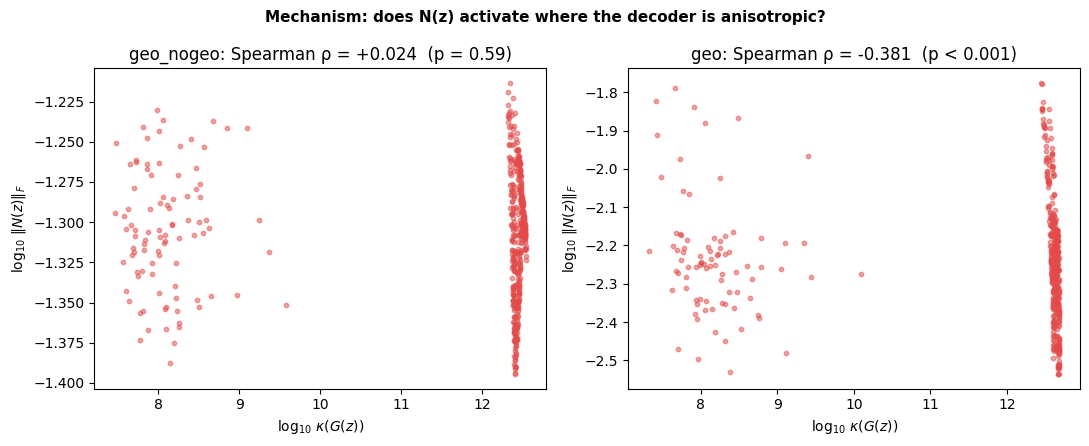

Saved /content/drive/MyDrive/Koopman/DeepKoopman_data/figures/mechanism_check.png


In [12]:
from scipy.stats import spearmanr

# Make sure seed0_models is populated (retrain if a fresh session)
needed = ['geo', 'geo_nogeo']
for name in needed:
    if name not in seed0_models:
        print(f'Retraining {name} seed=0 for mechanism plot...')
        for n, mode, hidden, lam in CONDITIONS:
            if n == name:
                seed0_models[name] = train(seed=0, mode=mode,
                                            hidden_corr=hidden, lam_geo=lam)
                break


@torch.no_grad()
def correction_frobenius(koop, z_batch):
    """||N(z)||_F at each z. Only meaningful for geo mode."""
    B = z_batch.shape[0]
    Nz = koop.correction(z_batch).view(B, koop.d, koop.d)
    return torch.norm(Nz.view(B, -1), dim=1).cpu().numpy()


def decoder_anisotropy(ae, z_batch):
    """kappa(G(z)) = lambda_max / lambda_min of J_D^T J_D at each z.

    Uses torch.func.jacrev to get the decoder Jacobian per-point.
    """
    from torch.func import jacrev
    decode = ae.decoder
    jac_fn = jacrev(lambda z: decode(z))
    kappas = []
    for z in z_batch:
        J = jac_fn(z)                   # (n=2, d=4)
        G = J.T @ J                     # (d, d) = (4, 4)
        eigs = torch.linalg.eigvalsh(G)
        eigs = torch.clamp(eigs, min=1e-12)
        kappas.append((eigs.max() / eigs.min()).item())
    return np.array(kappas)


def mechanism_data(result, n_samples=500):
    ae, koop = result['ae'], result['koop']
    ae.eval(); koop.eval()
    x_flat = X_te.reshape(-1, 2)
    idx = np.random.choice(len(x_flat), size=n_samples, replace=False)
    z_samples = ae.encode(x_flat[idx])
    n_fro  = correction_frobenius(koop, z_samples)
    kappas = decoder_anisotropy(ae, z_samples)
    rho, p = spearmanr(np.log(n_fro + 1e-12), np.log(kappas + 1e-12))
    return n_fro, kappas, rho, p


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ['geo_nogeo', 'geo']):
    n_fro, kappa, rho, p = mechanism_data(seed0_models[name])
    ax.scatter(np.log10(kappa), np.log10(n_fro + 1e-12),
               s=10, alpha=0.5, c='#E24B4A')
    ax.set_xlabel(r'$\log_{10}\,\kappa(G(z))$')
    ax.set_ylabel(r'$\log_{10}\,\|N(z)\|_F$')
    title = f'{name}: Spearman ρ = {rho:+.3f}'
    title += '  (p < 0.001)' if p < 1e-3 else f'  (p = {p:.3g})'
    ax.set_title(title)

plt.suptitle('Mechanism: does N(z) activate where the decoder is anisotropic?',
             fontsize=11, fontweight='bold')
plt.tight_layout()
mech_out = os.path.join(FIGS_DIR, 'mechanism_check.png')
plt.savefig(mech_out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {mech_out}')

## 10. What to do with the results

Send me back the summary table and the two plots. The conversation
about what the data actually supports depends on which of these
patterns we see:

**Pattern A: clean win.** `geo` clearly beats `vec_pm` across the std,
mechanism ρ is positive and meaningfully large (say > 0.3).
→ The geometric framing is earned. Write the paper as drafted, with this
ablation as a defensive section.

**Pattern B: ties on rollout, positive mechanism ρ.** `geo` ≈ `vec_pm`
in rollout error, but $N(z)$ still correlates with $\kappa(G(z))$.
→ Matrix structure isn't *necessary* for the rollout gain, but the
correction is still doing geometric work. Reframe as "geometry-aware
state-dependent correction" rather than "geometric necessity of matrix
structure."

**Pattern C: ties on rollout, no mechanism correlation.** `geo` ≈ `vec_pm`
and ρ ≈ 0. → The gain is just from added capacity. Drop the geometric
framing; the paper becomes "state-dependent corrections to deep Koopman."
Still publishable, but weaker.

**Pattern D: `geo_nogeo` matches `geo`.** The regularizer doesn't matter.
Drop it from the paper, or reframe as "this regularizer doesn't help on
this system."

I expect A or B, with maybe 60/30/8/2 odds for A/B/C/D respectively,
based on what I see in the cylinder results. But the data decides.
